## 1. Import necessary packages

In [ ]:
images = [
    '000000000785.jpg', '000000005477.jpg', '000000007278.jpg', '000000007278.jpg',
    '000000007977.jpg', '000000015440.jpg', '000000016502.jpg', '000000118594.jpg',
    '000000119911.jpg'
]

In [1]:
import cv2
import torch

from matplotlib import pyplot as plt
from util.utils import load_state_dict, load_checkpoint
from util.visualize import plot_bounding_boxes_on_image

/root/miniconda3/envs/detr/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/root/miniconda3/envs/detr/lib/python3.8/site-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.1 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


## 2. Load a model and class information

We encode class information into the checkpoint, use our defined `load_state_dict` to handle it.

In [9]:
from configs.relation_detr.relation_detr_resnet50_800_1333 import model
weight = load_checkpoint("https://github.com/xiuqhou/Relation-DETR/releases/download/v1.0.0/relation_detr_resnet50_800_1333_coco_1x.pth")
load_state_dict(model, weight)
model = model.eval()

INFO:Relation-DETR.util.utils:<All keys matched successfully>


In [2]:
from configs.dino_pp.dino_pp_resnet50_800_1333 import model
weight = load_checkpoint("/root/autodl-tmp/dino/dino-v3.1-cur-24ep_dino_pp_resnet50_800_1333/train/decoder-query-optm-v3.3.1-stable-group-div-sparse-loss_2025-01-21-15_36_02/best_ap.pth")
load_state_dict(model, weight)
model = model.eval()

Using /root/.cache/torch_extensions/py38_cu113 as PyTorch extensions root...
Detected CUDA files, patching ldflags
Emitting ninja build file /root/.cache/torch_extensions/py38_cu113/MultiScaleDeformableAttention/build.ninja...
Building extension module MultiScaleDeformableAttention...
Allowing ninja to set a default number of workers... (overridable by setting the environment variable MAX_JOBS=N)
[1/2] /usr/local/cuda/bin/nvcc  -DTORCH_EXTENSION_NAME=MultiScaleDeformableAttention -DTORCH_API_INCLUDE_EXTENSION_H -DPYBIND11_COMPILER_TYPE=\"_gcc\" -DPYBIND11_STDLIB=\"_libstdcpp\" -DPYBIND11_BUILD_ABI=\"_cxxabi1011\" -isystem /root/miniconda3/envs/detr/lib/python3.8/site-packages/torch/include -isystem /root/miniconda3/envs/detr/lib/python3.8/site-packages/torch/include/torch/csrc/api/include -isystem /root/miniconda3/envs/detr/lib/python3.8/site-packages/torch/include/TH -isystem /root/miniconda3/envs/detr/lib/python3.8/site-packages/torch/include/THC -isystem /usr/local/cuda/include -isy

In [26]:
image = cv2.imread("/root/autodl-tmp/data/COCO2017/images/val2017/000000005477.jpg")
torch_image = torch.tensor(image.transpose(2, 0, 1))

In [27]:
model.postprocessor.nms_iou_threshold = -1
model.postprocessor.select_box_nums_for_evaluation = 30

## 3. Inference on the image

In [28]:
with torch.no_grad():
    predictions = model([torch_image])[0]
# The following code also works:
# predictions = model(torch_image.unsqueeze(0))[0]

{'scores': tensor([0.9609, 0.6948, 0.3442, 0.3221, 0.2458, 0.2002, 0.1995, 0.1884, 0.1668,
        0.1555, 0.1530, 0.1456, 0.1453, 0.1405, 0.1377, 0.1345, 0.1336, 0.1277,
        0.1270, 0.1242]), 'boxes': tensor([[  8.7401, 104.2985, 634.2976, 289.4631],
        [ 40.7122, 249.3676, 140.6760, 274.1611],
        [ 40.9013, 248.8330, 166.7627, 274.8190],
        [130.2959, 248.6787, 156.3508, 269.1820],
        [129.8290, 248.7177, 171.3015, 270.4235],
        [593.0846, 227.6870, 640.2097, 267.9691],
        [589.0482, 257.2730, 639.9124, 271.5967],
        [592.4857, 256.4509, 639.5776, 267.1884],
        [129.7227, 248.9968, 212.2005, 276.6123],
        [130.0906, 248.6298, 192.4680, 271.4708],
        [589.3969, 260.2928, 639.7876, 271.0092],
        [123.1058, 248.7659, 185.2614, 275.4605],
        [591.7637, 246.4791, 639.5112, 267.9303],
        [133.1676, 256.5011, 153.9489, 268.5654],
        [ 43.6268, 231.7209, 154.4897, 272.7721],
        [130.8712, 248.8339, 143.9440, 265.4

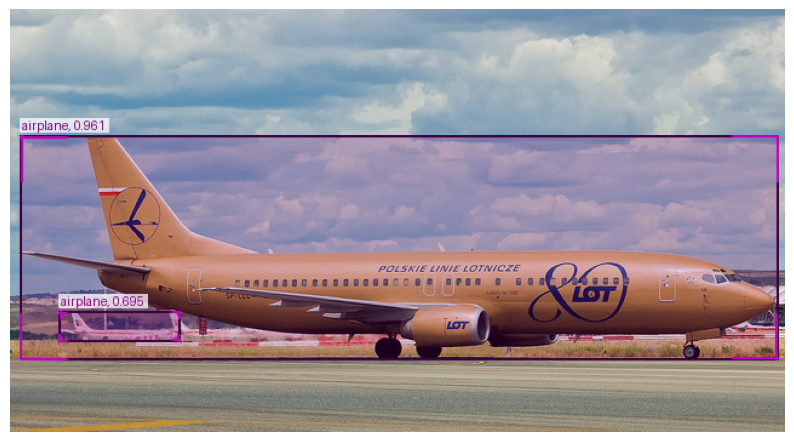

Total predictions for label 1: 24
Top predictions shown: 20


In [30]:
# 1. 获取 label=1 的掩码
mask = predictions['labels'] == 5

# 2. 过滤出 label=1 的结果
filtered_scores = predictions['scores'][mask]
filtered_boxes = predictions['boxes'][mask]
filtered_labels = predictions['labels'][mask]

# 3. 根据分数获取 top 20
if len(filtered_scores) > 20:
    # 获取前20个最高分数的索引
    top_k = 20
    top_scores, top_indices = torch.topk(filtered_scores, min(top_k, len(filtered_scores)))
    
    # 使用这些索引获取对应的框和标签
    top_boxes = filtered_boxes[top_indices]
    top_labels = filtered_labels[top_indices]
else:
    # 如果结果少于20个，全部保留
    top_scores = filtered_scores
    top_boxes = filtered_boxes
    top_labels = filtered_labels

# 4. 创建新的predictions字典
filtered_predictions = {
    'scores': top_scores,
    'boxes': top_boxes,
    'labels': top_labels
}
print(filtered_predictions)


# 5. 可视化结果
image_for_show = plot_bounding_boxes_on_image(
    image=cv2.cvtColor(image, cv2.COLOR_BGR2RGB),
    boxes=filtered_predictions["boxes"],
    labels=filtered_predictions["labels"],
    scores=filtered_predictions["scores"],
    classes=model.CLASSES,
    show_conf=0.5,
    font_scale=1.0,
    box_thick=2,
    text_alpha=0.75,
)

# 显示结果
plt.figure(figsize=(10, 10))
plt.imshow(image_for_show)
plt.axis('off')
plt.show()

# 打印结果数量
print(f"Total predictions for label 1: {len(filtered_scores)}")
print(f"Top predictions shown: {len(top_scores)}")

In [29]:
print(predictions['labels'])

tensor([5, 5, 5, 5, 5, 1, 5, 5, 5, 5, 5, 5, 1, 5, 5, 5, 5, 5, 5, 1, 5, 5, 1, 5,
        1, 9, 5, 5, 5, 5])


## 4. Visualize results

In [16]:
image_for_show = plot_bounding_boxes_on_image(
    image=cv2.cvtColor(image, cv2.COLOR_BGR2RGB),
    boxes=predictions["boxes"],
    labels=predictions["labels"],
    scores=predictions["scores"],
    classes=model.CLASSES,  # class information
    show_conf=0.5,
    font_scale=1.0,
    box_thick=2,
    text_alpha=0.75,
)

In [11]:
image_for_show = plot_bounding_boxes_on_image(
    image=cv2.cvtColor(image, cv2.COLOR_BGR2RGB),
    boxes=predictions["boxes"],
    labels=predictions["labels"],
    scores=predictions["scores"],
    classes=model.CLASSES,
    show_conf=-1,  # 设置一个负值，通常这会禁用置信度显示
    font_scale=0,  # 设置字体大小为0，禁用文本显示
    box_thick=2,   # 保持框的粗细
    text_alpha=0,  # 文本透明度设为0
)

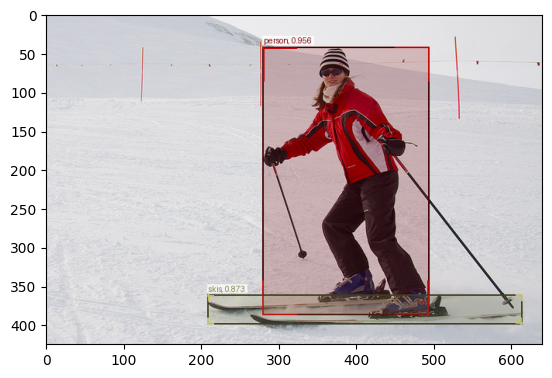

In [17]:
plt.imshow(image_for_show)